Notebook for data acquisition and running of LSTM algorithm on simulated data 

In [2]:
import pandas as pd
import numpy as np   
import torch
import torch.nn as nn 
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import math

In [ ]:
# label maker and datafile reader for my filename conventions 
def labelmaker(events=None, sp_density=None, t_density=None, noise=None, filename = None, folder = None): 
    '''creates labels based on my naming convention for different files, keeps it consistent and easy'''
    if folder: 
        folder = folder + '/'

    if filename: 
        datafile = str(filename) 
    else: 
        datafile = str(events) + 'ev_' + str(sp_density) + 'spd_' + str(t_density) + 'td_n' + str(noise)
    

    labelfile = 'labels_' + datafile + '.csv'
    sourcefile = 'sources_' + datafile + '.csv'
    ai_labelfile = datafile + '_results' + '.csv'
    centroidfile = datafile + '_centroids' + '.csv'
    datafile = datafile + '.csv'

    if folder: 
        datafile = folder + datafile 
        centroidfile = folder + centroidfile 
        ai_labelfile = folder + ai_labelfile 
        labelfile = folder + labelfile 
        sourcefile = folder + sourcefile 

    
    return datafile, labelfile, sourcefile

def datapull(events=None, sp_density=None, t_density=None, noise=None, filename = None, folder = None): 
    '''Returns data tensors for the given filenames'''
    datafile, labelfile, sourcefile = labelmaker(events, sp_density, t_density, noise, filename, folder)

    data = []
    with open(datafile, 'r') as f:
        for line in f:
            values = [float(v) for v in line.strip().split(',') if v.strip()]  # Convert to float

            if len(values) % 3 != 0:
                print(f"Warning: Skipping malformed row with {len(values)} values (not a multiple of 3)")
                continue  # Skip malformed rows
            
            coords = torch.tensor(values).reshape(-1, 3)  # Convert to (N, 3) tensor
            data.append(coords)  # Store as a tensor

    labelread = pd.read_csv(labelfile)
    labels = np.array(labelread['labels'])
    labels = torch.tensor(labels)

    columns = ['x[px]', 'y[px]', 't[s]']
    sourceread = pd.read_csv(sourcefile)
    sources = np.array(sourceread[columns])
    sources = torch.tensor(sources)

    return data, labels, sources
            


In [4]:
# 1. Data Acquisition

# 1.1. Read files 
data, train_labels, train_sources = datapull(filename='10000ev_mixed_n0')
train_labels = train_labels.to(torch.float32)
train_sources = train_sources.to(torch.float32)

train_lengths = torch.tensor([len(event) for event in data])

#pad sequences to the longest event length
train_data = pad_sequence(data, batch_first=True, padding_value = 0.0)
train_data = train_data.to(torch.float32)

# #-------#
data, test_labels, test_sources = datapull(filename='test1000ev_n0_es10')
test_labels = test_labels.to(torch.float32)
test_sources = test_sources.to(torch.float32)

test_lengths = torch.tensor([len(event) for event in data])

#padding 
test_data = pad_sequence(data, batch_first=True, padding_value = 0.0)
test_data = test_data.to(torch.float32)



In [5]:
## use lengths to find the event boundaries 

### EVENT BOUNDARIES
boundaries = []

for i in range(10000):
    sample = train_data[i][:train_lengths[i]]
    limits = torch.tensor([
        torch.min(sample[:, 0]),
        torch.min(sample[:, 1]),
        torch.min(sample[:, 2]), 
        torch.max(sample[:, 0]),
        torch.max(sample[:, 1])
    ])
    boundaries.append(limits)

# Stack the list of tensors into a single 2D tensor
boundaries = torch.stack(boundaries)

### TEST BOUNDARIES 
test_boundaries = []

for i in range(1000):
    sample = test_data[i][:test_lengths[i]]
    limits = torch.tensor([
        torch.min(sample[:, 0]),
        torch.min(sample[:, 1]),
        torch.min(sample[:, 2]), 
        torch.max(sample[:, 0]),
        torch.max(sample[:, 1])

    ])
    test_boundaries.append(limits)

# Stack the list of tensors into a single 2D tensor
test_boundaries = torch.stack(test_boundaries)



In [6]:
# LSTM Model Definition 

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers 

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, lengths):
        packed_x = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed_x)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)

        last_outputs = out[torch.arange(out.size(0)), lengths-1]
        out = self.fc(last_outputs)

        return out

class sourceLSTM(nn.Module): 
    def __init__(self, input_size=3, hidden_size=32, num_layers=4, dropout=0):
        super(sourceLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)

        self.fc = nn.Linear(hidden_size, 3)

    def forward(self, x, lengths): 
        x_packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)

        packed_output, (hidden, cell) = self.lstm(x_packed)

        output = hidden[-1]
        output = self.fc(output)

        return output


In [7]:
### custom loss to include a penalty for sources clustered together
threshold = 0.1

def MSE_penalty(y_pred, y_true): 
    v_penalty = -torch.sum(torch.var(y_pred, dim=0))

    y_pred = y_pred.detach().numpy()
    y_true = np.array(y_true)

    mse = (np.mean((y_pred - y_true)**2))*1e-5

    return v_penalty + mse

In [8]:
## custom loss to penalize a source existing outside the reality box 

# for each event: 
    # define reality box
    # penalty = distance that prediction is outside the x y and time bounds
    # penalty = abs(minx - pred) if predx < minx or abs(maxx - pred) if predx > maxx else 0
    # penalty += pred_time - realtime if pred_time - realtime else 0

    # make it a series of if then else statements 
                    #[0,    1,     2,    3,    4]
# boundary order is [minx, miny, mint, maxx, maxy]

def reality_penalty(y_pred, y_true, realitybox):
    penalty = 0 
    for i in range(len(y_pred)): 
        if y_pred[i][0] < realitybox[i][0]: 
            penalty += realitybox[i][0] - y_pred[i][0] # check min x
        elif y_pred[i][0] > realitybox[i][3]: 
            penalty += y_pred[i][0] - realitybox[i][3] # check max x 
        if y_pred[i][1] < realitybox[i][1]:
            penalty += realitybox[i][1] - y_pred[i][1] # check min y 
        elif y_pred[i][1] > realitybox[i][4]:
            penalty += y_pred[i][1] - realitybox[i][4]
        if y_pred[i][2] > realitybox[i][2]:
            penalty += y_pred[i][2] - realitybox[i][2]
    
    penalty = penalty/(len(y_pred)*30)
    return penalty


In [9]:
#### PARAMETER IMPORT
model = sourceLSTM()
model.load_state_dict(torch.load('/home/cgillesp/Downloads/LSTM/model parameters/sourceLSTM2.1.pth'))
model.eval()
loss_fn = nn.MSELoss() #MSE_penalty() #nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

Epoch:1
Train Loss:0.000461634190287441
Test Loss:0.11772547662258148
Epoch:2
Train Loss:0.1466178148984909
Test Loss:0.03511118143796921
Epoch:3
Train Loss:0.03997799754142761
Test Loss:0.013168547302484512
Epoch:4
Train Loss:0.014051582664251328
Test Loss:0.04303327947854996
Epoch:5
Train Loss:0.05219427868723869
Test Loss:0.032011501491069794
Epoch:6
Train Loss:0.03708411008119583
Test Loss:0.0245805773884058
Epoch:7
Train Loss:0.02747129276394844
Test Loss:0.020409798249602318
Epoch:8
Train Loss:0.021735602989792824
Test Loss:0.017520492896437645
Epoch:9
Train Loss:0.01696716621518135
Test Loss:0.02211209386587143
Epoch:10
Train Loss:0.021036842837929726
Test Loss:0.02625272423028946
Epoch:11
Train Loss:0.024865973740816116
Test Loss:0.025968659669160843
Epoch:12
Train Loss:0.02408061921596527
Test Loss:0.024503715336322784
Epoch:13
Train Loss:0.022657327353954315
Test Loss:0.024008244276046753
Epoch:14
Train Loss:0.02268524281680584
Test Loss:0.020902404561638832
Epoch:15
Train Lo

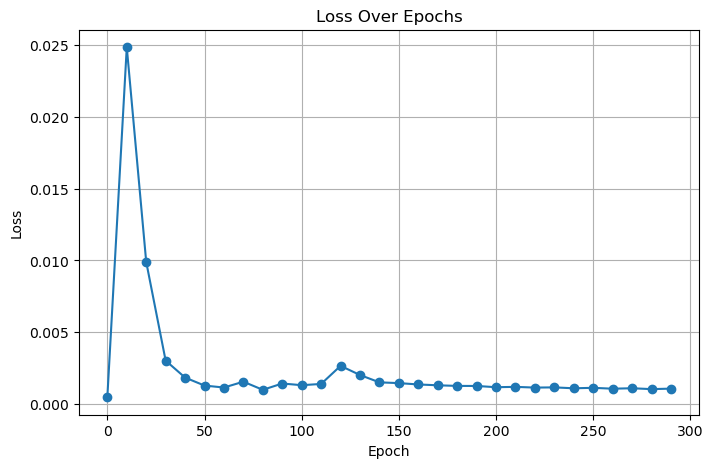

In [9]:
# Training and Evaluation Loop 

epochs = 300 
losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(train_data, train_lengths)
    loss = loss_fn(y_pred, train_sources) + reality_penalty(y_pred, train_sources, boundaries) #loss_fn(y_pred, train_sources)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:  # Store every tenth epoch
            loss = loss.detach().numpy()
            losses.append((epoch, loss))

    model.eval()
    with torch.no_grad():
        y_pred_test = model(test_data, test_lengths)
        test_loss = loss_fn(y_pred_test, test_sources) + reality_penalty(y_pred_test, test_sources, test_boundaries) #loss_fn(y_pred_test, test_sources)
    
    print(f"Epoch:{epoch +1}")
    print(f"Train Loss:{loss}")
    print(f"Test Loss:{test_loss}")


epochs, loss_values = zip(*losses)  # Unpacking the list of tuples
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_values, marker='o', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.grid()
plt.savefig('losses_10000_mixed.png')



In [10]:
### MODEL RESULTS 
predictions = model(train_data, train_lengths)
predictions = predictions.detach().numpy()
test_predictions = model(test_data, test_lengths)
test_predictions = test_predictions.detach().numpy()

In [11]:
len(predictions), len(train_sources), len(test_predictions), len(test_sources)

(10000, 10000, 1000, 1000)

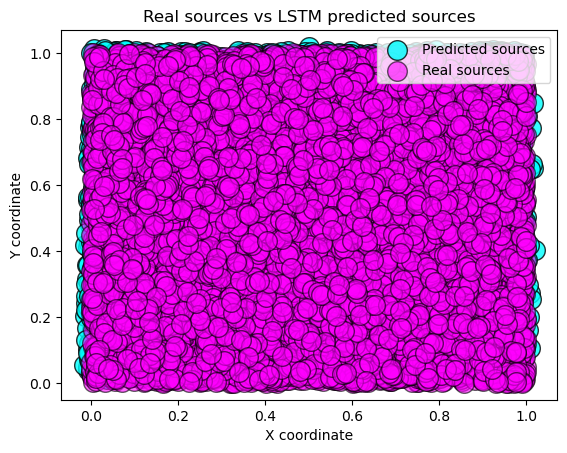

In [12]:
### PLOTTING TRAINING DATA 
plt.scatter(predictions[:,2], predictions[:,1], c='cyan', s = 200, label='Predicted sources', alpha = 0.8, edgecolors='black')
plt.scatter(train_sources[:,2], train_sources[:,1], c='magenta', s=200, label='Real sources', alpha=0.6, edgecolors='black')
plt.title("Real sources vs LSTM predicted sources")
plt.ylabel("Y coordinate")
plt.xlabel("X coordinate")
plt.legend()

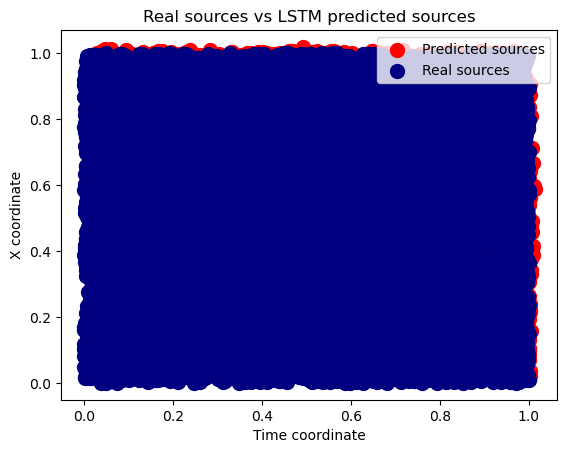

In [13]:
plt.scatter(predictions[:,0], predictions[:,1], c='red', s=100, label='Predicted sources')
plt.scatter(train_sources[:,0], train_sources[:,1], c='navy', s=100, label='Real sources')
plt.title("Real sources vs LSTM predicted sources")
plt.ylabel("X coordinate")
plt.xlabel("Time coordinate")
plt.legend()

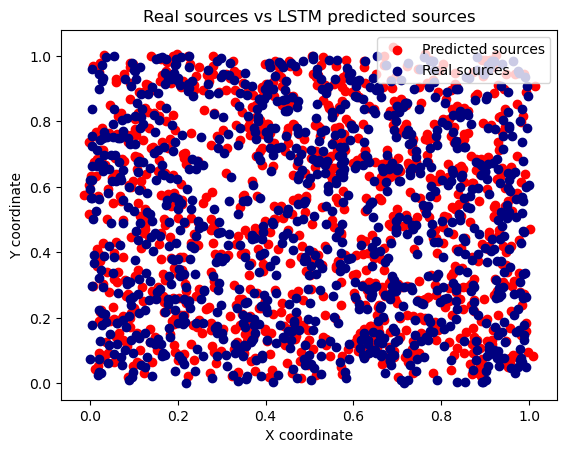

In [14]:
#### PLOTTING TEST DATA 
plt.scatter(test_predictions[:,2], test_predictions[:,1], c='red', label='Predicted sources')
plt.scatter(test_sources[:,2], test_sources[:,1], c='navy', label='Real sources')
plt.title("Real sources vs LSTM predicted sources")
plt.ylabel("Y coordinate")
plt.xlabel("X coordinate")
plt.legend()

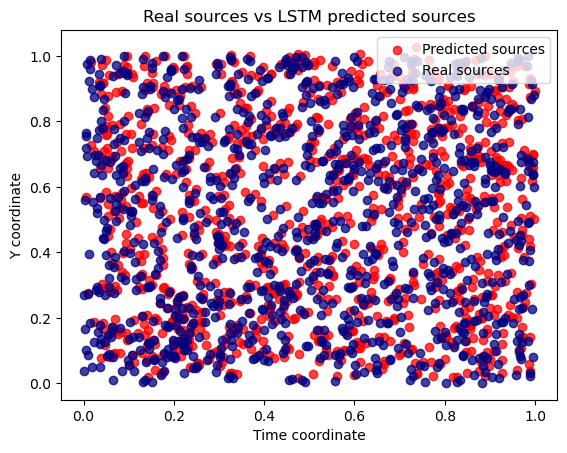

In [15]:
plt.scatter(test_predictions[:,0], test_predictions[:,1], c='red', label='Predicted sources', alpha = 0.75)
plt.scatter(test_sources[:,0], test_sources[:,1], c='navy', label='Real sources', alpha=0.75)
plt.title("Real sources vs LSTM predicted sources")
plt.ylabel("Y coordinate")
plt.xlabel("Time coordinate")
plt.legend()

In [16]:
#### L1 TRAINING LOSS
pred = model(train_data, train_lengths)
loss_fn2 = nn.L1Loss()
lossxyt = loss_fn2(pred, train_sources)
lossyt = loss_fn2(pred[:,1:2], train_sources[:,1:2])
lossxy = loss_fn2(pred[:,:1], train_sources[:,:1])
print(lossxyt, lossxy, lossyt)

tensor(0.0112, grad_fn=<MeanBackward0>) tensor(0.0117, grad_fn=<MeanBackward0>) tensor(0.0121, grad_fn=<MeanBackward0>)


In [17]:
data, test_labels, test_sources = datapull(filename='10000ev_mixed_n0')
test_labels = test_labels.to(torch.float32)
test_sources = test_sources.to(torch.float32)

test_lengths = torch.tensor([len(event) for event in data])

#padding 
test_data = pad_sequence(data, batch_first=True, padding_value = 0.0)
test_data = test_data.to(torch.float32)

In [18]:
#### L1 TESTING LOSS
pred = model(train_data, train_lengths)
lossxyt = loss_fn2(pred, train_sources)
lossyt = loss_fn2(pred[:,1:2], train_sources[:,1:2])
lossxy = loss_fn2(pred[:,:1], train_sources[:,:1])
print(lossxyt) 
print(lossxy) 
print(lossyt)

tensor(0.0112, grad_fn=<MeanBackward0>)
tensor(0.0117, grad_fn=<MeanBackward0>)
tensor(0.0121, grad_fn=<MeanBackward0>)


In [19]:
diff = torch.norm(pred-train_sources, dim=1)
torch.min(diff), torch.max(diff), torch.median(diff)
min = (diff == torch.min(diff)).nonzero(as_tuple=False)
max = (diff == torch.max(diff)).nonzero(as_tuple=False)
med = (diff == torch.median(diff)).nonzero(as_tuple=False)
min, max, med

(tensor([[907]]), tensor([[1633]]), tensor([[3818]]))

In [20]:
minimum = data[907].numpy()
min_pred = pred[907].detach().numpy()
maximum = data[1633].numpy()
max_pred = pred[1633].detach().numpy()
median = data[3818].numpy()
median_pred = pred[3818].detach().numpy()



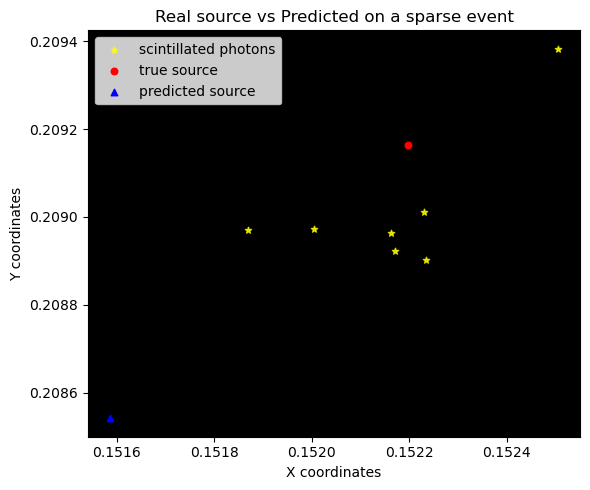

In [25]:
plt.figure(figsize=(6, 5))
ax = plt.gca()
ax.set_facecolor('black')

# Scatter with small points, colored by density-ish appearance
plt.scatter(minimum[:,0], minimum[:,1], s=22, color='yellow', alpha=0.8, marker='*', label = 'scintillated photons')
plt.scatter(train_sources[907][0], train_sources[907][1], s=22, color='red', label = 'true source')
plt.scatter(min_pred[0], min_pred[1], s=22, color='blue', marker='^', label = 'predicted source')

# Plot styling
plt.xlabel("X coordinates")
plt.ylabel("Y coordinates")
plt.title("Real source vs Predicted on a sparse event")
plt.legend()


# Set white tick labels

plt.tight_layout()
plt.show()

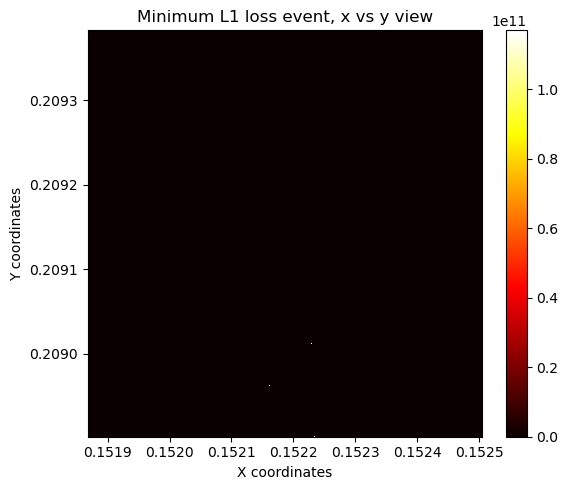

In [24]:
### Heatmap
plt.figure(figsize=(6, 5))
hist = plt.hist2d(minimum[:,0], minimum[:,1], bins=500, cmap='hot', density=True)

# Add colorbar and labels
plt.colorbar(hist[3])
plt.xlabel('X coordinates')
plt.ylabel('Y coordinates')
plt.title('Minimum L1 loss event, x vs y view')
plt.tight_layout()

plt.show()

In [23]:
### SAVING THE SUPER AWESOME MODEL
# torch.save(model.state_dict(), '/home/cgillesp/Downloads/LSTM/sourceLSTM0.0.pth')

In [24]:
# torch.save(model.state_dict(), '/home/cgillesp/Downloads/LSTM/sourceLSTM0.1.pth')

In [25]:
#torch.save(model.state_dict(), '/home/cgillesp/Downloads/LSTM/model parameters/sourceLSTM1.075.pth')

In [26]:
### saving mixed model 
torch.save(model.state_dict(), '/home/cgillesp/Downloads/LSTM/model parameters/sourceLSTM2.1.pth')